# Logistic Regression from Scratch

## Objective
Implement binary Logistic Regression from scratch using NumPy.

To be implemented:
1. Sigmoid
2. Linear score
3. Predicted probabilities
4. Cost function
5. Gradients
6. One gradient-descent update
7. Complete gradient descent
8. Class prediction
9. Accuracy
10. Decision boundary

**Rules:** Use NumPy. Do not use `sklearn.linear_model.LogisticRegression`. Complete only cells marked **YOUR CODE HERE**.

## 1. Import Libraries

In [2]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

## 2. Load the Dataset

`X` contains two features and `y` contains binary class labels.

Inspect the shapes before continuing.

In [3]:
X = np.array([
    [1.0, 1.0], [1.5, 1.2], [2.0, 1.8], [2.2, 2.0],
    [2.5, 2.3], [3.0, 2.8], [3.2, 3.0], [3.5, 3.2],
    [4.0, 3.8], [4.5, 4.0], [5.0, 4.5], [5.5, 5.0]
])

y = np.array([0,0,0,0,0,0,1,1,1,1,1,1])

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (12, 2)
y shape: (12,)


In [4]:
X

array([[1. , 1. ],
       [1.5, 1.2],
       [2. , 1.8],
       [2.2, 2. ],
       [2.5, 2.3],
       [3. , 2.8],
       [3.2, 3. ],
       [3.5, 3.2],
       [4. , 3.8],
       [4.5, 4. ],
       [5. , 4.5],
       [5.5, 5. ]])

## 3. Visualize the Dataset

Plot Class 0 and Class 1 using different markers or colours.

- Feature 1 → x-axis
- Feature 2 → y-axis

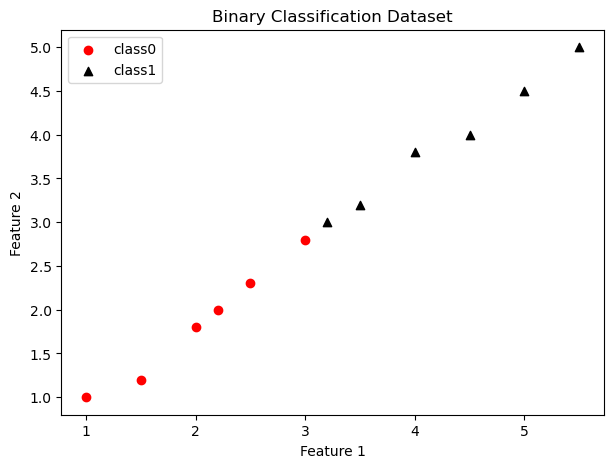

In [5]:
plt.figure(figsize=(7,5))
plt.scatter(X[y==0,0],X[y==0,1],color="red",label="class0")
plt.scatter(X[y==1,0],X[y==1,1],marker='^',color="black",label="class1")
plt.legend()

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Binary Classification Dataset")
plt.show()

## 4. Logistic Regression Model

The model first calculates

$$
z = Xw+b
$$

and then

$$
\hat y = \sigma(z)
$$

where

$$
\sigma(z)=\frac{1}{1+e^{-z}}
$$

If `X.shape = (m,n)` and `w.shape = (n,)`, then `X @ w` has shape `(m,)`.

## 5. Step 1 — Implement Sigmoid

### Task
Complete `sigmoid(z)`.

Use `np.exp()`. Your function should work for both a scalar and a NumPy array.

In [6]:
def sigmoid(z):
    sig=1/(1+np.exp(-z))
    return(sig)
    
    pass

In [7]:
test_values = np.array([-10, -2, 0, 2, 10])
print(sigmoid(test_values))

# Remember: sigmoid(0) should be 0.5

[4.53978687e-05 1.19202922e-01 5.00000000e-01 8.80797078e-01
 9.99954602e-01]


## 6. Step 2 — Compute the Linear Score

Implement

`z = X @ w + b`

### Hint
Use the `@` operator for matrix-vector multiplication.

In [8]:
def compute_z(X, w, b):
    z=(X@w)+b
    return(z)
    pass

In [9]:
w = np.zeros(X.shape[1])
b = 0.1
z = compute_z(X, w, b)

print("z:", z)
print("z shape:", z.shape)

z: [0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1]
z shape: (12,)


## 7. Step 3 — Compute Predicted Probabilities

The predicted probability is

$$
\hat y = \sigma(Xw+b)
$$

### Task
Implement `predict_probability()` using the functions you have already written.

In [10]:
def predict_probability(X, w, b):
    pred=sigmoid(X@w+b)
    return(pred)
    pass

In [11]:
probabilities = predict_probability(X, w, b)
print(probabilities)

[0.52497919 0.52497919 0.52497919 0.52497919 0.52497919 0.52497919
 0.52497919 0.52497919 0.52497919 0.52497919 0.52497919 0.52497919]


## 8. Step 4 — Implement the Cost Function

For binary Logistic Regression,

$$
J =
-\frac{1}{m}\sum_{i=1}^{m}
\left[
y^{(i)}\log(\hat y^{(i)})
+
(1-y^{(i)})\log(1-\hat y^{(i)})
\right]
$$

Use `np.clip()` to avoid taking `log(0)`.

### Hint
```python
epsilon = 1e-15
probabilities = np.clip(probabilities, epsilon, 1-epsilon)
```

In [12]:
def compute_cost(X, y, w, b):
    m = X.shape[0]
    z = compute_z(X, w, b)
    y_hat=sigmoid(z)
    probabilities = predict_probability(X, w, b)
    epsilon = 1e-15
    probabilities = np.clip(probabilities, epsilon, 1-epsilon)
    cost=(-1/m)*np.sum(y*np.log(y_hat)+(1-y)*np.log(1-y_hat))

    return cost

In [13]:
initial_cost = compute_cost(X, y, w, b)
print("Initial cost:", initial_cost)

# With w=0 and b=0, every probability is 0.5.

Initial cost: 0.6943966600735709


## 9. Step 5 — Compute the Gradients

The gradients are

$$
dw = \frac{1}{m}X^T(\hat y-y)
$$

$$
db = \frac{1}{m}\sum(\hat y-y)
$$

### Shape check

If

```text
X.shape = (m,n)
w.shape = (n,)
y.shape = (m,)
```

then

```text
X.T.shape = (n,m)
y_hat-y   = (m,)
dw        = (n,)
```

Do not use a loop over training examples. Rather, use broadcasting.

In [14]:
def compute_gradients(X, y, w, b):
    m = X.shape[0]
    probabilities = predict_probability(X, w, b)
    
    # Use @ (matrix multiplication) so dw has shape (2,) matching w
    dw = (1 / m) * (X.T @ (probabilities - y))
    db = (1 / m) * np.sum(probabilities - y)
    
    return dw, db

## 10. Step 6 — Implement One Gradient-Descent Update

Use

$$
w := w - \alpha dw
$$

$$
b := b - \alpha db
$$

### Task
Compute the gradients, update `w` and `b`, and return them.

In [15]:
def gradient_descent_step(X, y, w, b, learning_rate):
    dw, db = compute_gradients(X, y, w, b)
    
    w = w - learning_rate * dw
    b = b - learning_rate * db
    
    return w,b

In [16]:
def train_logistic_regression(X, y, learning_rate=0.1, num_iterations=1000):
    w = np.zeros(X.shape[1])
    b = 0.0
    cost_history = []
    
    for i in range(num_iterations):
        cost = compute_cost(X, y, w, b)
        cost_history.append(cost)
        w, b = gradient_descent_step(X, y, w, b, learning_rate)
        
    return w, b, cost_history

## 12. Train the Model

Use learning rate `0.1` and `1000` iterations.

In [17]:
learning_rate = 0.1
num_iterations = 1000

w, b, cost_history = train_logistic_regression(X, y, learning_rate, num_iterations)

print("Final weights:", w)
print("Final bias:   ", b)
print("Final cost:   ", cost_history[-1])  # Use [-1] to print the last cost value

Final weights: [0.93237099 1.04970645]
Final bias:    -5.656246822064307
Final cost:    0.20888817201258206


## 13. Plot the Cost

Plot iteration number against cost.

### Expected observation
The cost should generally decrease during training.

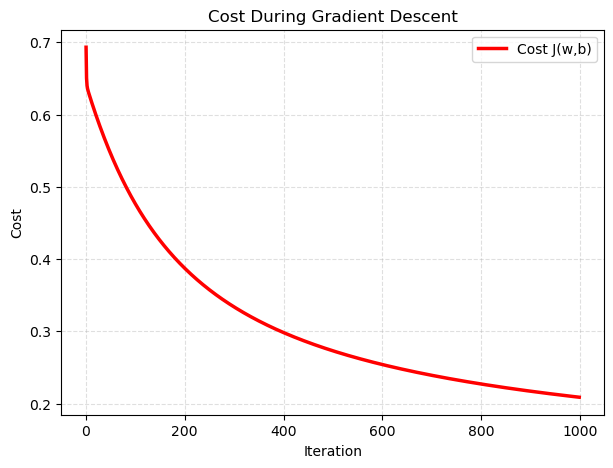

In [25]:
plt.figure(figsize=(7, 5))

# Plot iteration index vs cost history
plt.plot(cost_history, color='red', linewidth=2.5, label='Cost J(w,b)')

plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.title("Cost During Gradient Descent")
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend()
plt.show()

## 14. Step 8 — Convert Probabilities into Class Predictions

Use the rule

$$
\hat y =
\begin{cases}
1 & \text{if probability} \geq 0.5\\
0 & \text{otherwise}
\end{cases}
$$

### Hint
```python
(probabilities >= threshold).astype(int)
```

In [19]:
def predict(X, w, b, threshold=0.5):
    # Compute probabilities using existing function
    probabilities = predict_probability(X, w, b)
    # Apply classification threshold rule
    return (probabilities >= threshold).astype(int)

In [20]:
y_pred = predict(X, w, b)

print("Predictions:", y_pred)
print("Actual:     ", y)

Predictions: [0 0 0 0 0 1 1 1 1 1 1 1]
Actual:      [0 0 0 0 0 0 1 1 1 1 1 1]


## 15. Step 9 — Calculate Accuracy

$$
Accuracy =
\frac{\text{Number of correct predictions}}
{\text{Total number of predictions}}
$$

### Task
Implement `accuracy()` using NumPy.

In [21]:
def accuracy(y_true, y_pred):
    return np.mean(y_true == y_pred)

In [50]:
print("Accuracy:", accuracy(y, y_pred))

Accuracy: 0.9166666666666666


## 16. Step 10 — Visualize the Decision Boundary

For two features, the decision boundary is

$$
w_1x_1+w_2x_2+b=0
$$

Therefore,

$$
x_2=-\frac{w_1x_1+b}{w_2}
$$

### Task
Plot the two classes and the learned decision boundary.

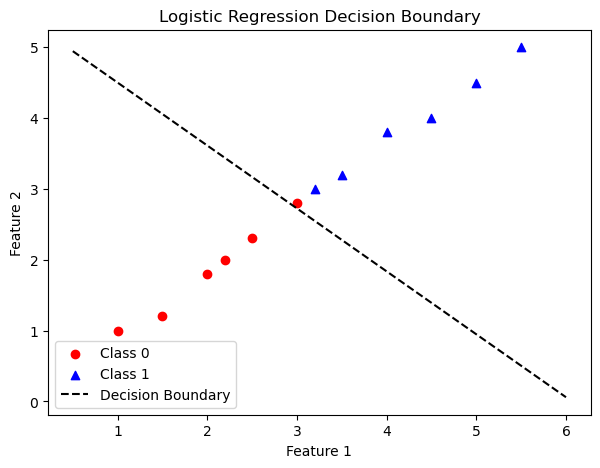

In [27]:
plt.figure(figsize=(7, 5))
plt.scatter(X[y == 0, 0], X[y == 0, 1], color="red", label="Class 0")
plt.scatter(X[y == 1, 0], X[y == 1, 1], color="blue", marker="^", label="Class 1")
x1_vals = np.linspace(X[:, 0].min() - 0.5, X[:, 0].max() + 0.5, 100)
x2_vals = -(w[0] * x1_vals + b) / w[1]
plt.plot(x1_vals, x2_vals, color="black", linestyle="--", label="Decision Boundary")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Logistic Regression Decision Boundary")
plt.legend()
plt.show()

# Test your understanding — Learning Rate Experiment

Train the model using:

- `0.001`
- `0.1`
- `1.0`

Record the final cost and accuracy.

### Question
Which learning rate appears most appropriate for this dataset, and why?


ANS:$\alpha = 1.0$ is the most appropriate because it minimizes the cost the fastest (down to $0.10011$) and achieves $100\%$ accuracy within the 1,000 iterations without diverging. 

In [23]:
learning_rates = [0.001, 0.1, 1.0]

for lr in learning_rates:
    w_lr, b_lr, costs_lr = train_logistic_regression(X, y, learning_rate=lr, num_iterations=1000)
    pred_lr = predict(X, w_lr, b_lr)
    acc_lr = accuracy(y, pred_lr)
    print(f"Learning Rate: {lr:<5} | Final Cost: {costs_lr[-1]:.5f} | Accuracy: {acc_lr * 100:.1f}%")

Learning Rate: 0.001 | Final Cost: 0.61993 | Accuracy: 50.0%
Learning Rate: 0.1   | Final Cost: 0.20889 | Accuracy: 91.7%
Learning Rate: 1.0   | Final Cost: 0.10011 | Accuracy: 100.0%


# Test your understanding — Classification Threshold

Use thresholds:

- `0.3`
- `0.5`
- `0.7`

Compare the predictions and accuracy.

### Question
Why can changing the threshold change the classification result without changing the learned weights?


Ans:-Weights and bias only determine the predicted probabilities, while the threshold is a separate post-processing decision rule that shifts the decision boundary to map those fixed probabilities into classes.

In [24]:
thresholds = [0.3, 0.5, 0.7]

for th in thresholds:
    pred_th = predict(X, w, b, threshold=th)
    acc_th = accuracy(y, pred_th)
    print(f"Threshold: {th} | Predictions: {pred_th} | Accuracy: {acc_th * 100:.1f}%")

Threshold: 0.3 | Predictions: [0 0 0 0 0 1 1 1 1 1 1 1] | Accuracy: 91.7%
Threshold: 0.5 | Predictions: [0 0 0 0 0 1 1 1 1 1 1 1] | Accuracy: 91.7%
Threshold: 0.7 | Predictions: [0 0 0 0 0 0 0 1 1 1 1 1] | Accuracy: 91.7%


**Important:** Use vectorized NumPy operations wherever possible instead of loops.